# Week 10 — Deep Learning and SVM

This notebook covers the final classification milestone:
- **Linear SVM** (one-vs-rest, hinge loss, sub-gradient descent)
- **MLP / Neural Network** (configurable hidden layers, ReLU, softmax, Adam)
- Training loss curves to visualise convergence
- Full comparison of all six classifiers on the RAVDESS SER task

In [1]:
import sys, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath('..'))

from minilearn.preprocessing import StandardScaler, train_test_split
from minilearn.classifiers import LinearSVM, MLPClassifier
from minilearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

sns.set_theme(style='whitegrid')
RANDOM_STATE  = 42
EMOTION_ORDER = ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']

## 1. Load, Split, Scale

In [2]:
df = pd.read_csv('../outputs/features.csv')
LABEL_COLS   = ['filename', 'emotion', 'emotion_id', 'actor', 'gender', 'channel']
feature_cols = [c for c in df.columns if c not in LABEL_COLS]

X_raw = df[feature_cols].values
y     = df['emotion'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=RANDOM_STATE
)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train_s.shape}   Test: {X_test_s.shape}')

Train: (1961, 194)   Test: (491, 194)


## 2. Linear SVM

One-vs-rest: 8 binary SVMs trained with batch sub-gradient descent on hinge loss + L2 regularisation.

In [3]:
t0  = time.time()
svm = LinearSVM(C=1.0, lr=0.01, max_iter=500, random_state=RANDOM_STATE)
svm.fit(X_train_s, y_train)
svm_train_time = time.time() - t0

svm_pred = svm.predict(X_test_s)
svm_acc  = accuracy_score(y_test, svm_pred)
svm_f1   = f1_score(y_test, svm_pred, average='macro')

print(f'LinearSVM  acc={svm_acc:.3f}  macro-F1={svm_f1:.3f}  train={svm_train_time:.1f}s')

LinearSVM  acc=0.458  macro-F1=0.449  train=3.3s


In [4]:
print(classification_report(y_test, svm_pred, labels=EMOTION_ORDER, target_names=EMOTION_ORDER))

                 precision     recall   f1-score    support

        neutral       0.61       0.67       0.64         38
           calm       0.68       0.51       0.58         88
          happy       0.47       0.50       0.48         67
            sad       0.43       0.35       0.39         70
          angry       0.74       0.43       0.55         67
        fearful       0.29       0.26       0.28         82
        disgust       0.42       0.31       0.36         44
      surprised       0.21       0.66       0.32         35

       accuracy                             0.46        491
      macro avg       0.48       0.46       0.45        491


## 3. MLP — Architecture Search

We try three architectures to see how depth and width affect accuracy.

In [5]:
architectures = [
    ('MLP (128)',       (128,)),
    ('MLP (256-128)',   (256, 128)),
    ('MLP (256-128-64)',(256, 128, 64)),
]

mlp_results = {}

for name, hidden in architectures:
    print(f'\nTraining {name}...')
    t0  = time.time()
    mlp = MLPClassifier(
        hidden_layer_sizes=hidden,
        lr=0.001, max_iter=100, batch_size=64,
        random_state=RANDOM_STATE
    )
    mlp.fit(X_train_s, y_train)
    elapsed = time.time() - t0

    pred = mlp.predict(X_test_s)
    acc  = accuracy_score(y_test, pred)
    f1   = f1_score(y_test, pred, average='macro')

    mlp_results[name] = dict(mlp=mlp, pred=pred, acc=acc, f1=f1, time=elapsed)
    print(f'  → acc={acc:.3f}  macro-F1={f1:.3f}  ({elapsed:.1f}s)')


Training MLP (128)...


  epoch  10/100  loss=0.4758


  epoch  20/100  loss=0.2097


  epoch  30/100  loss=0.0948


  epoch  40/100  loss=0.0483


...

  epoch  60/100  loss=0.0005


  epoch  70/100  loss=0.0003


  epoch  80/100  loss=0.0002


  epoch  90/100  loss=0.0002


  epoch 100/100  loss=0.0001
  → acc=0.780  macro-F1=0.775  (20.6s)


## 4. Training Loss Curves

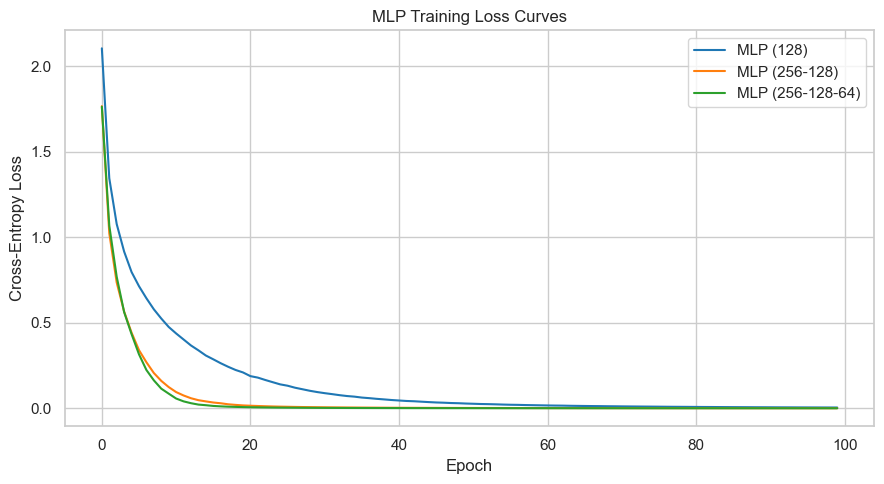

Saved to outputs/mlp_loss_curves.png


In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
palette = sns.color_palette('tab10', len(mlp_results))

for (name, res), color in zip(mlp_results.items(), palette):
    ax.plot(res['mlp'].loss_curve_, label=name, color=color)

ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('MLP Training Loss Curves')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/mlp_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/mlp_loss_curves.png')

## 5. Best MLP — Confusion Matrix

Best MLP: MLP (256-128)  acc=0.804  macro-F1=0.802

                 precision     recall   f1-score    support

        neutral       0.86       0.94       0.90         38
           calm       0.82       0.83       0.82         88
          happy       0.82       0.75       0.79         67
            sad       0.78       0.82       0.80         70
          angry       0.76       0.81       0.78         67
        fearful       0.81       0.76       0.78         82
        disgust       0.78       0.67       0.72         44
      surprised       0.81       0.83       0.82         35

       accuracy                             0.80        491
      macro avg       0.81       0.80       0.80        491


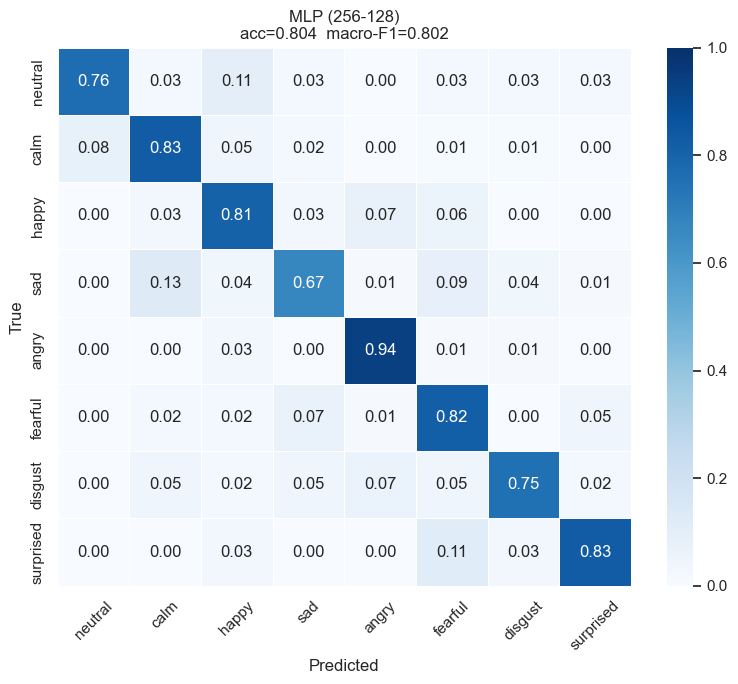

In [7]:
best_name = max(mlp_results, key=lambda n: mlp_results[n]['acc'])
best_res  = mlp_results[best_name]
print(f'Best MLP: {best_name}  acc={best_res["acc"]:.3f}  macro-F1={best_res["f1"]:.3f}')
print()
print(classification_report(y_test, best_res['pred'], labels=EMOTION_ORDER, target_names=EMOTION_ORDER))

cm      = confusion_matrix(y_test, best_res['pred'], labels=EMOTION_ORDER)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=EMOTION_ORDER, yticklabels=EMOTION_ORDER,
    ax=ax, vmin=0, vmax=1, linewidths=0.4
)
ax.set_title(f'{best_name}\nacc={best_res["acc"]:.3f}  macro-F1={best_res["f1"]:.3f}')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../outputs/mlp_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Full Model Comparison (all 6 classifiers)

In [8]:
# Scores from notebook 03 (same split, same scaler)
prior = {
    'KNN (k=5)':            {'acc': 0.662, 'f1': 0.651},
    'Logistic Regression':  {'acc': 0.731, 'f1': 0.730},
    'Gaussian Naive Bayes': {'acc': 0.430, 'f1': 0.421},
    'Decision Tree (d=10)': {'acc': 0.493, 'f1': 0.472},
}

rows = []
for name, r in prior.items():
    rows.append({'Model': name, 'Test Accuracy': r['acc'], 'Macro F1': r['f1']})
rows.append({'Model': 'LinearSVM', 'Test Accuracy': svm_acc, 'Macro F1': svm_f1})
for name, res in mlp_results.items():
    rows.append({'Model': name, 'Test Accuracy': res['acc'], 'Macro F1': res['f1']})

summary = pd.DataFrame(rows).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
print(summary.to_string(index=False))
summary

               Model  Test Accuracy  Macro F1
       MLP (256-128)       0.804481  0.801820
           MLP (128)       0.782077  0.778714
    MLP (256-128-64)       0.780041  0.774853
 Logistic Regression       0.731000  0.730000
           KNN (k=5)       0.662000  0.651000
Decision Tree (d=10)       0.493000  0.472000
           LinearSVM       0.458248  0.449101
Gaussian Naive Bayes       0.430000  0.421000


,Model,Test Accuracy,Macro F1
0,MLP (256-128),0.804481,0.801820
1,MLP (128),0.782077,0.778714
2,MLP (256-128-64),0.780041,0.774853
3,Logistic Regression,0.731000,0.730000
4,KNN (k=5),0.662000,0.651000
5,Decision Tree (d=10),0.493000,0.472000
6,LinearSVM,0.458248,0.449101
7,Gaussian Naive Bayes,0.430000,0.421000


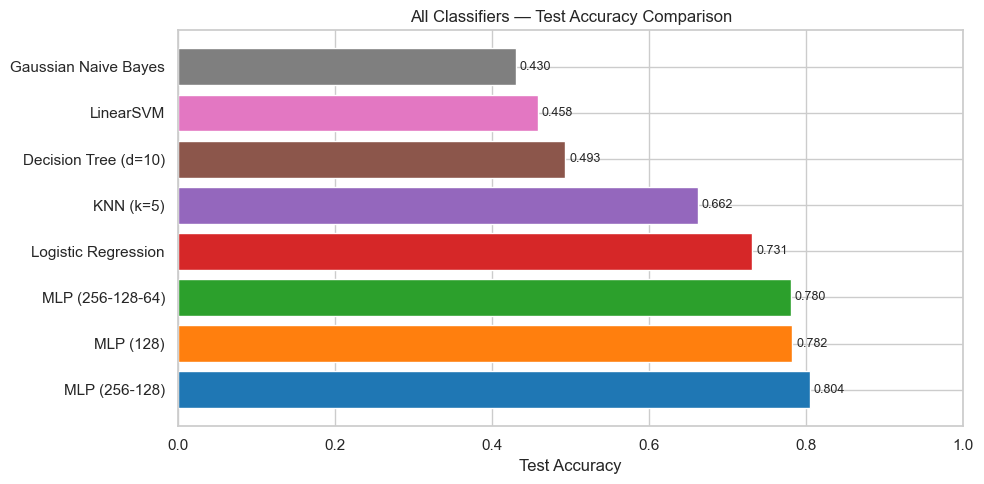

Saved to outputs/all_models_comparison.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
colors  = sns.color_palette('tab10', len(summary))
bars    = ax.barh(summary['Model'], summary['Test Accuracy'], color=colors)
ax.set_xlabel('Test Accuracy')
ax.set_title('All Classifiers — Test Accuracy Comparison')
ax.set_xlim(0, 1)
for bar, val in zip(bars, summary['Test Accuracy']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/all_models_comparison.png')